In [1]:
import numpy as np
from sklearn.datasets import load_diabetes

In [2]:
X,y = load_diabetes(return_X_y=True)

In [3]:

X

array([[ 0.03807591,  0.05068012,  0.06169621, ..., -0.00259226,
         0.01990749, -0.01764613],
       [-0.00188202, -0.04464164, -0.05147406, ..., -0.03949338,
        -0.06833155, -0.09220405],
       [ 0.08529891,  0.05068012,  0.04445121, ..., -0.00259226,
         0.00286131, -0.02593034],
       ...,
       [ 0.04170844,  0.05068012, -0.01590626, ..., -0.01107952,
        -0.04688253,  0.01549073],
       [-0.04547248, -0.04464164,  0.03906215, ...,  0.02655962,
         0.04452873, -0.02593034],
       [-0.04547248, -0.04464164, -0.0730303 , ..., -0.03949338,
        -0.00422151,  0.00306441]], shape=(442, 10))

In [4]:
X.shape

(442, 10)

In [5]:
y.shape

(442,)

### Using Sklearns linear regression


In [6]:
from sklearn.model_selection import train_test_split

In [7]:

X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=2)

In [8]:
print(X_train.shape)
print(X_test.shape)

(353, 10)
(89, 10)


In [9]:
from sklearn.linear_model import LinearRegression

In [10]:
reg = LinearRegression()

In [12]:
reg.fit(X_train,y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [13]:
y_pred = reg.predict(X_test)

In [14]:
from sklearn.metrics import r2_score

In [15]:
r2_score(y_test,y_pred)

0.439933866156897

In [16]:
reg.coef_

array([  -9.15865318, -205.45432163,  516.69374454,  340.61999905,
       -895.5520019 ,  561.22067904,  153.89310954,  126.73139688,
        861.12700152,   52.42112238])

In [17]:
reg.intercept_

np.float64(151.88331005254167)

### Making our own Linear Regression Class

In [50]:
lr = MeraLR()


In [49]:
class MeraLR:

    def __init__(self):
        self.coef_ = None
        self.intercept_ = None

    def fit(self,X_train,y_train):
        X_train = np.insert(X_train,0,1,axis=1)

        #calaculate coeff
        betas = np.linalg.inv(np.dot(X_train.T,X_train)).dot(X_train.T).dot(y_train)
        self.intercept_ = betas[0]
        self.coef_ = betas[1:]
        print(betas)
        
    def predict(self,X_test):
        y_pred = np.dot(X_test,self.coef_) + self.intercept_
        return y_pred


        
        

In [51]:
lr.fit(X_train,y_train)

[ 151.88331005   -9.15865318 -205.45432163  516.69374454  340.61999905
 -895.5520019   561.22067904  153.89310954  126.73139688  861.12700152
   52.42112238]


In [52]:

X_train.shape

(353, 10)

In [53]:
np.insert(X_train,0,1,axis=1).shape

(353, 11)

In [57]:
y_pred = lr.predict(X_test)

In [58]:
r2_score(y_test,y_pred)

0.4399338661568968

In [59]:
lr.coef_ 

array([  -9.15865318, -205.45432163,  516.69374454,  340.61999905,
       -895.5520019 ,  561.22067904,  153.89310954,  126.73139688,
        861.12700152,   52.42112238])

In [60]:
lr.intercept_

np.float64(151.88331005254167)

In [61]:
X_train_single = X_train[:,0].reshape(-1,1)
X_test_single = X_test[:,0].reshape(-1,1)

In [69]:
X_train_single.shape

(353, 1)

In [70]:
lr = MeraLR()

lr.fit(X_train_single, y_train)

[150.49572046 361.59113196]


In [71]:
y_pred = lr.predict(X_test_single)

In [72]:
from sklearn.metrics import r2_score

print(r2_score(y_test, y_pred))

-0.04923210429343894


In [65]:
print("Slope:", lr.coef_)
print("Intercept:", lr.intercept_)

Slope: [361.59113196]
Intercept: 150.49572046274747


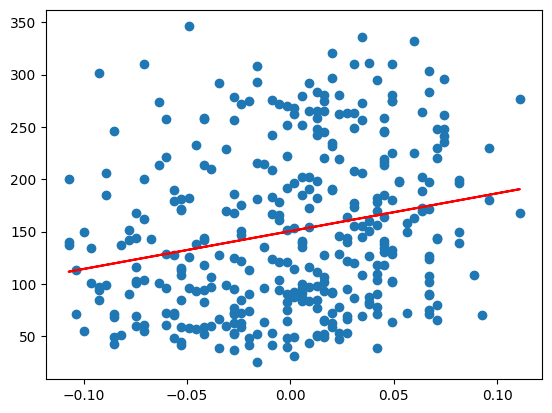

In [66]:
import matplotlib.pyplot as plt

plt.scatter(X_train_single, y_train)
plt.plot(X_train_single, lr.predict(X_train_single), color="red")
plt.show()